Step-1: Data Loading and Observation

In [97]:
import pandas as pd

In [98]:
import os
print(os.listdir())

['app.py', 'cleaned_dataset.csv', 'cleaned_dataset_2.csv', 'Forest_Fires_Datsaset_India.csv', 'fwi1.ipynb', 'FWI_notebook.ipynb', 'myenv', 'Project Implementation Doc', 'requirements.txt', 'ridge.pkl', 'scaler.pkl', 'static', 'templates']


In [99]:
df = pd.read_csv("Forest_Fires_Datsaset_India.csv")

In [100]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Karnataka
1,2,6,2012,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,Karnataka
2,3,6,2012,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Karnataka
3,4,6,2012,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,Karnataka
4,5,6,2012,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,Karnataka


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          724 non-null    int64  
 1   month        724 non-null    int64  
 2   year         724 non-null    int64  
 3   Temperature  724 non-null    float64
 4   RH           724 non-null    float64
 5   Ws           724 non-null    float64
 6   Rain         724 non-null    float64
 7   FFMC         724 non-null    float64
 8   DMC          724 non-null    float64
 9   DC           724 non-null    float64
 10  ISI          724 non-null    float64
 11  BUI          724 non-null    float64
 12  FWI          724 non-null    float64
 13  Classes      724 non-null    object 
 14  Region       724 non-null    object 
dtypes: float64(10), int64(3), object(2)
memory usage: 85.0+ KB


In [102]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [103]:
df.duplicated().sum()

0

In [104]:
import numpy as np

df = pd.read_csv("Forest_Fires_Datsaset_India.csv")

# Drop unnecessary columns
df = df.drop(columns=['Classes', 'day', 'year','month'])

# Recalculate FWI using real relationships
df['FWI'] = (
    0.4 * df['Temperature'] +
    0.3 * df['ISI'] +
    0.2 * df['DC'] +
    0.1 * df['DMC'] -
    0.3 * df['RH'] -
    0.2 * df['Rain'] +
    0.1 * df['Ws'] +
    np.random.normal(0, 2, len(df))  # small noise
)

# Make sure no negative FWI values
df['FWI'] = df['FWI'].clip(lower=0)

print(df[['Temperature', 'RH', 'Ws', 'Rain', 'FWI']].head(10))
print("\nFWI Stats:")
print(df['FWI'].describe())

   Temperature    RH    Ws  Rain       FWI
0         29.0  57.0  18.0   0.0  0.000000
1         29.0  61.0  13.0   1.3  0.000000
2         26.0  82.0  22.0  13.1  0.000000
3         25.0  89.0  13.0   2.5  0.000000
4         27.0  77.0  16.0   0.0  0.000000
5         31.0  67.0  14.0   0.0  0.912829
6         33.0  54.0  13.0   0.0  7.203818
7         30.0  73.0  15.0   0.0  2.007606
8         25.0  88.0  13.0   0.2  0.000000
9         28.0  79.0  12.0   0.0  0.000000

FWI Stats:
count    724.000000
mean      14.583765
std       16.607697
min        0.000000
25%        0.000000
50%        7.482356
75%       26.892566
max       64.044207
Name: FWI, dtype: float64


### Step 2 - Data Exploration and Data Preprocessing

Outlier Detection using Box plots

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

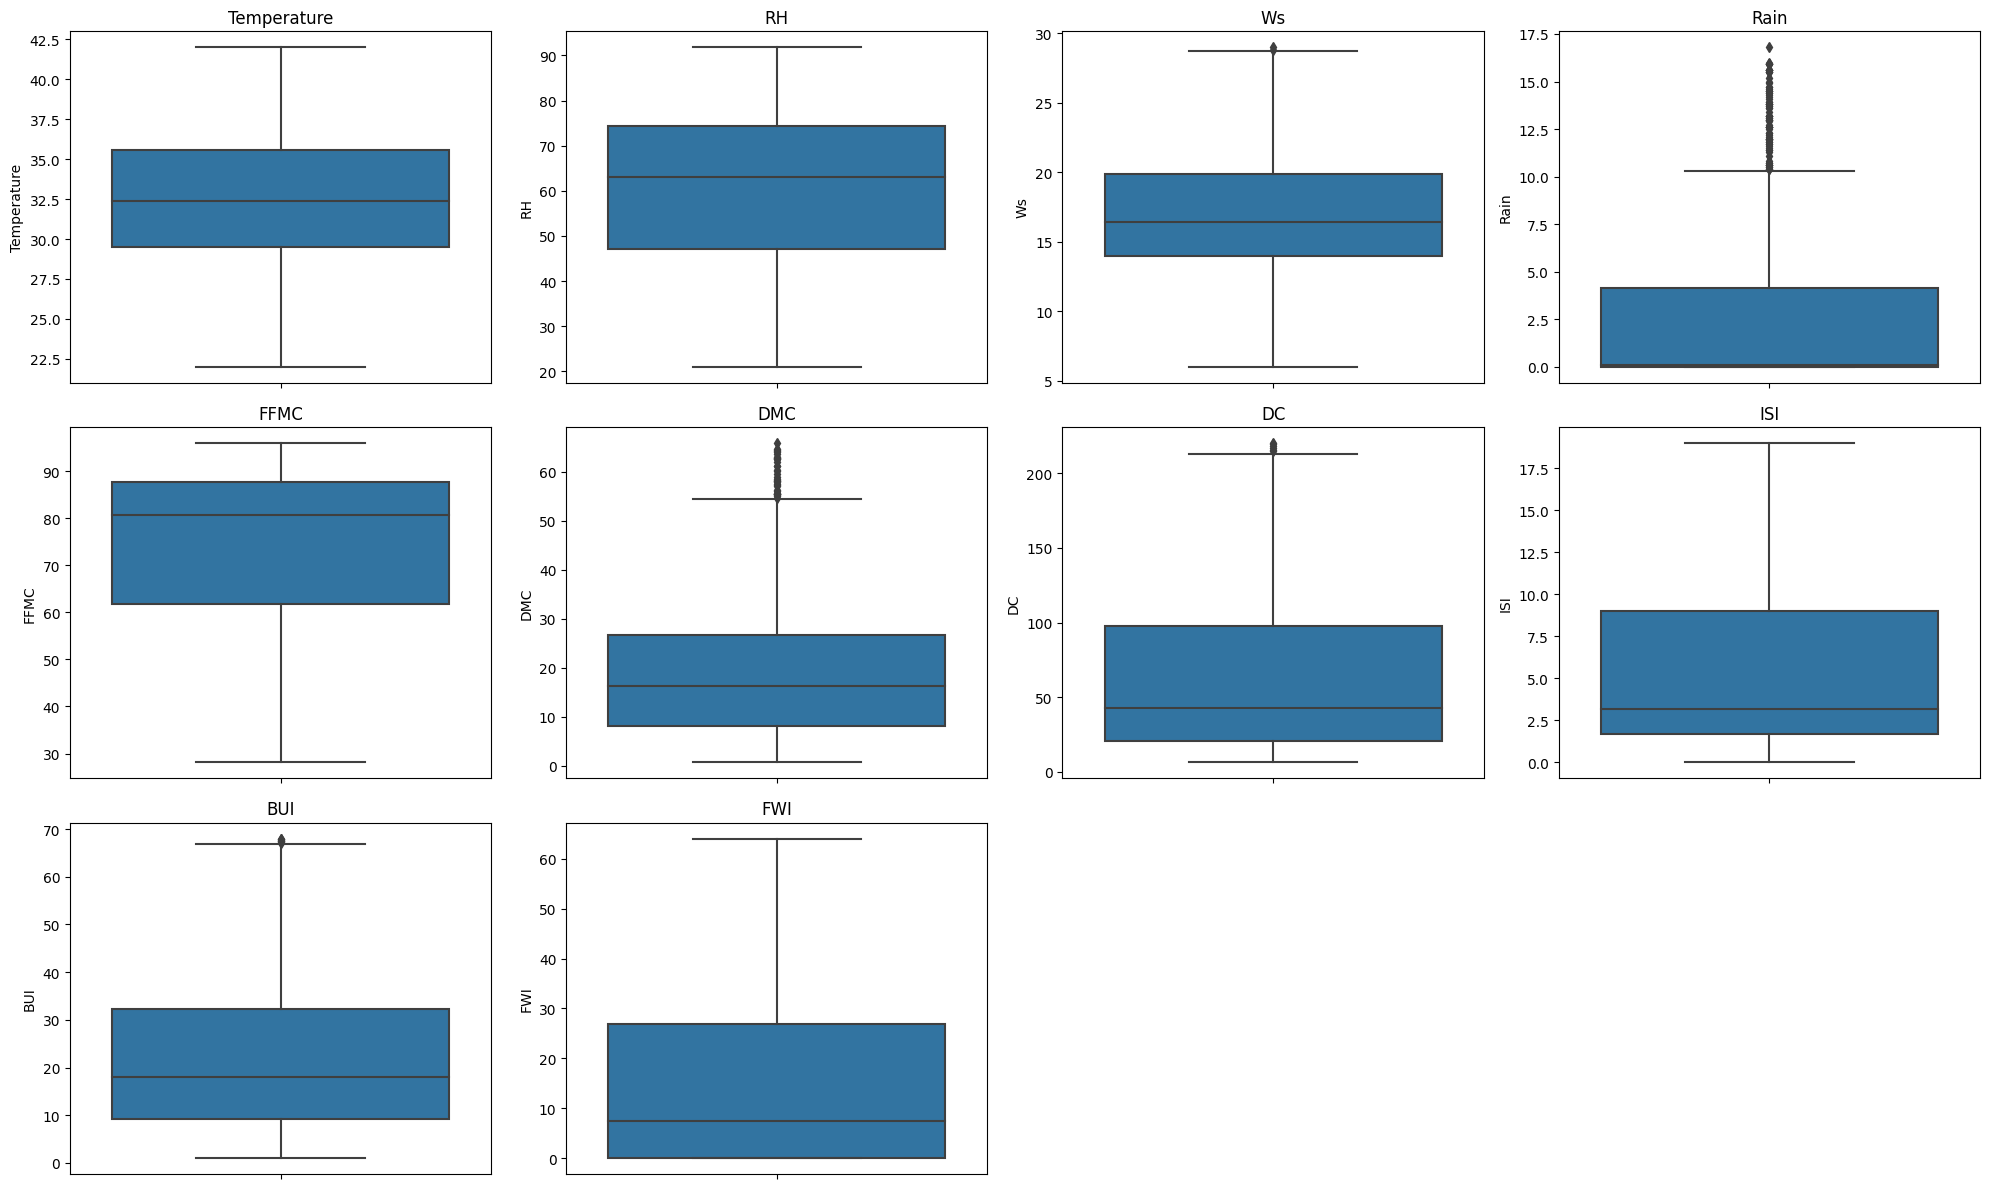

In [107]:
plt.figure(figsize=(20, 12))
n_cols = len(numeric_cols)
n_rows = (n_cols // 4) + 1

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Statistical method to find ouliers

In [108]:
import numpy as np

In [109]:
outliers = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_indices = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outliers[col] = outlier_indices
    print(f"{col}: {len(outlier_indices)} outliers")

Temperature: 0 outliers
RH: 0 outliers
Ws: 2 outliers
Rain: 86 outliers
FFMC: 0 outliers
DMC: 36 outliers
DC: 6 outliers
ISI: 0 outliers
BUI: 7 outliers
FWI: 0 outliers


Visualization of data using histograms

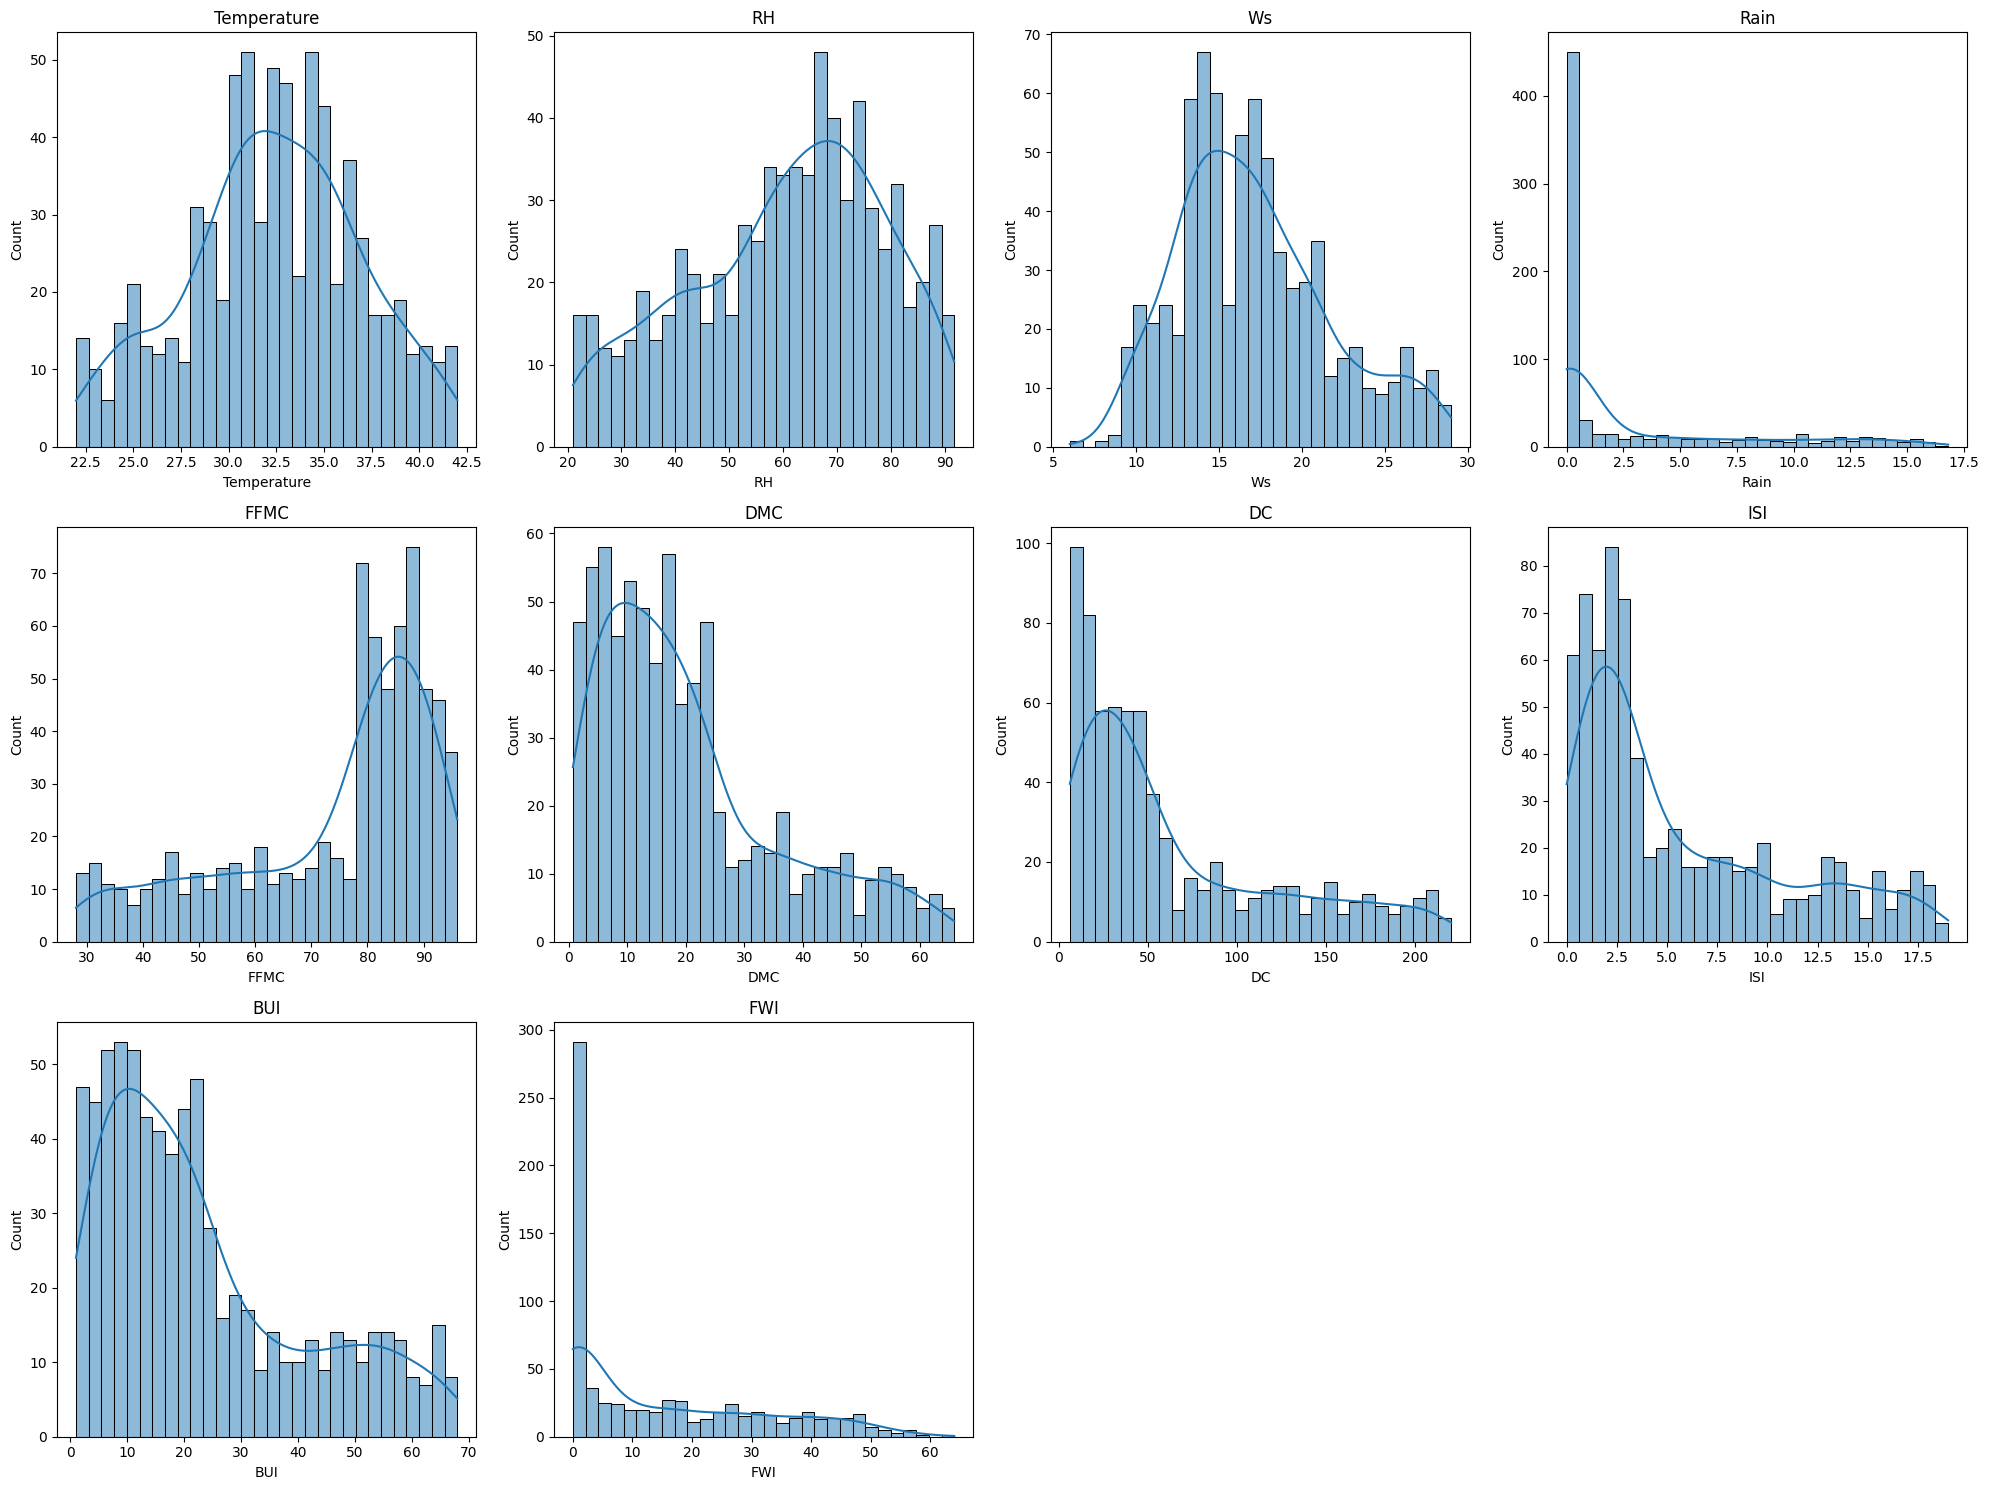

In [110]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = len(numeric_cols)
n_rows = (n_cols // 4) + (1 if n_cols % 4 else 0)

plt.figure(figsize=(20, 5 * n_rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 4, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

Visualization using density plots 

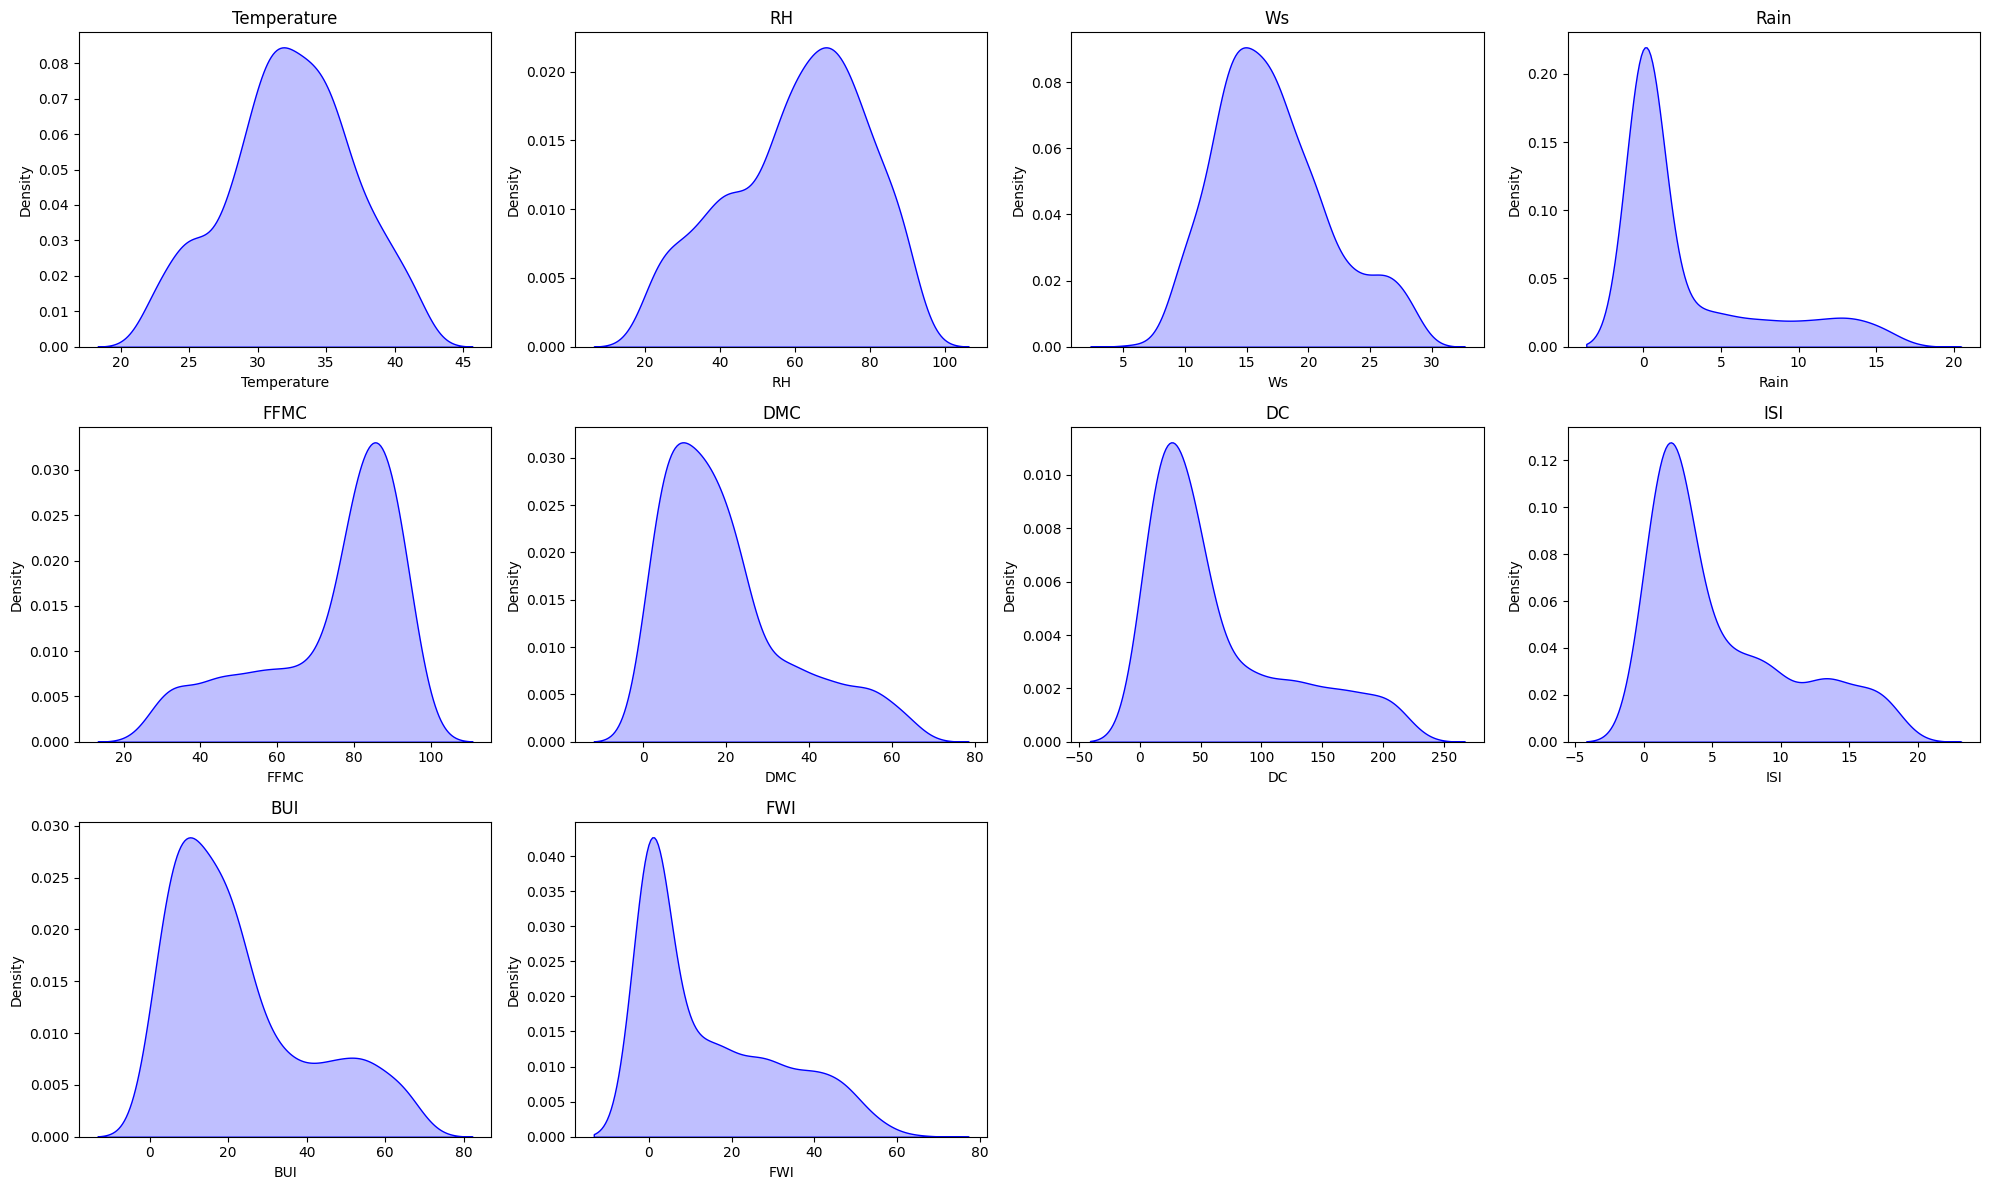

In [111]:
plt.figure(figsize=(20, 12))
n_cols = len(numeric_cols)
n_rows = (n_cols // 4) + 1

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 4, i)

    # KDE plot with updated syntax
    sns.kdeplot(df[col], fill=True, color='blue')

    plt.title(col)

plt.tight_layout()
plt.show()

Correlation Matrix

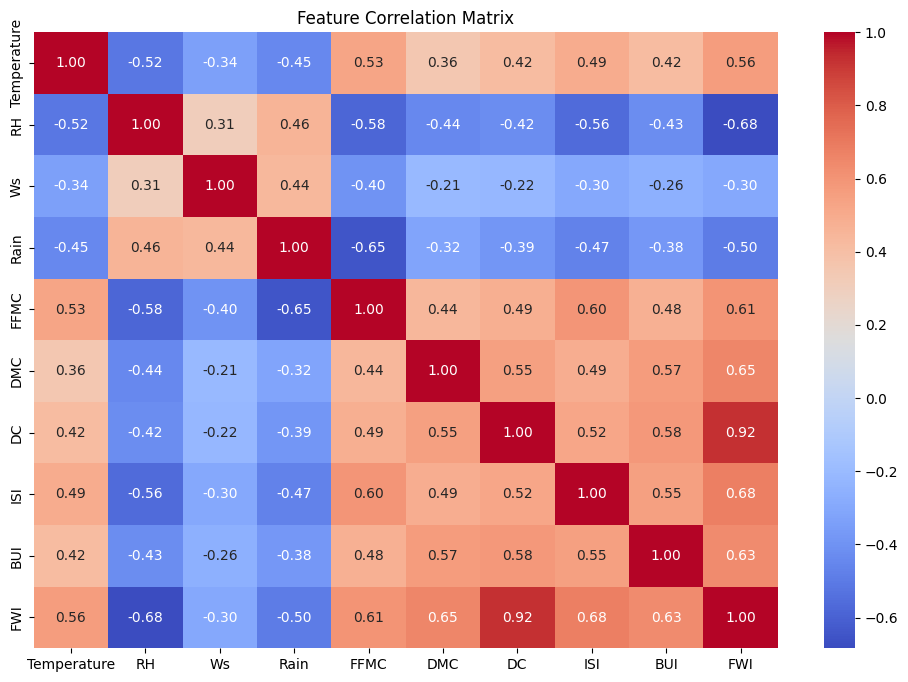

In [112]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

Scatter Plot

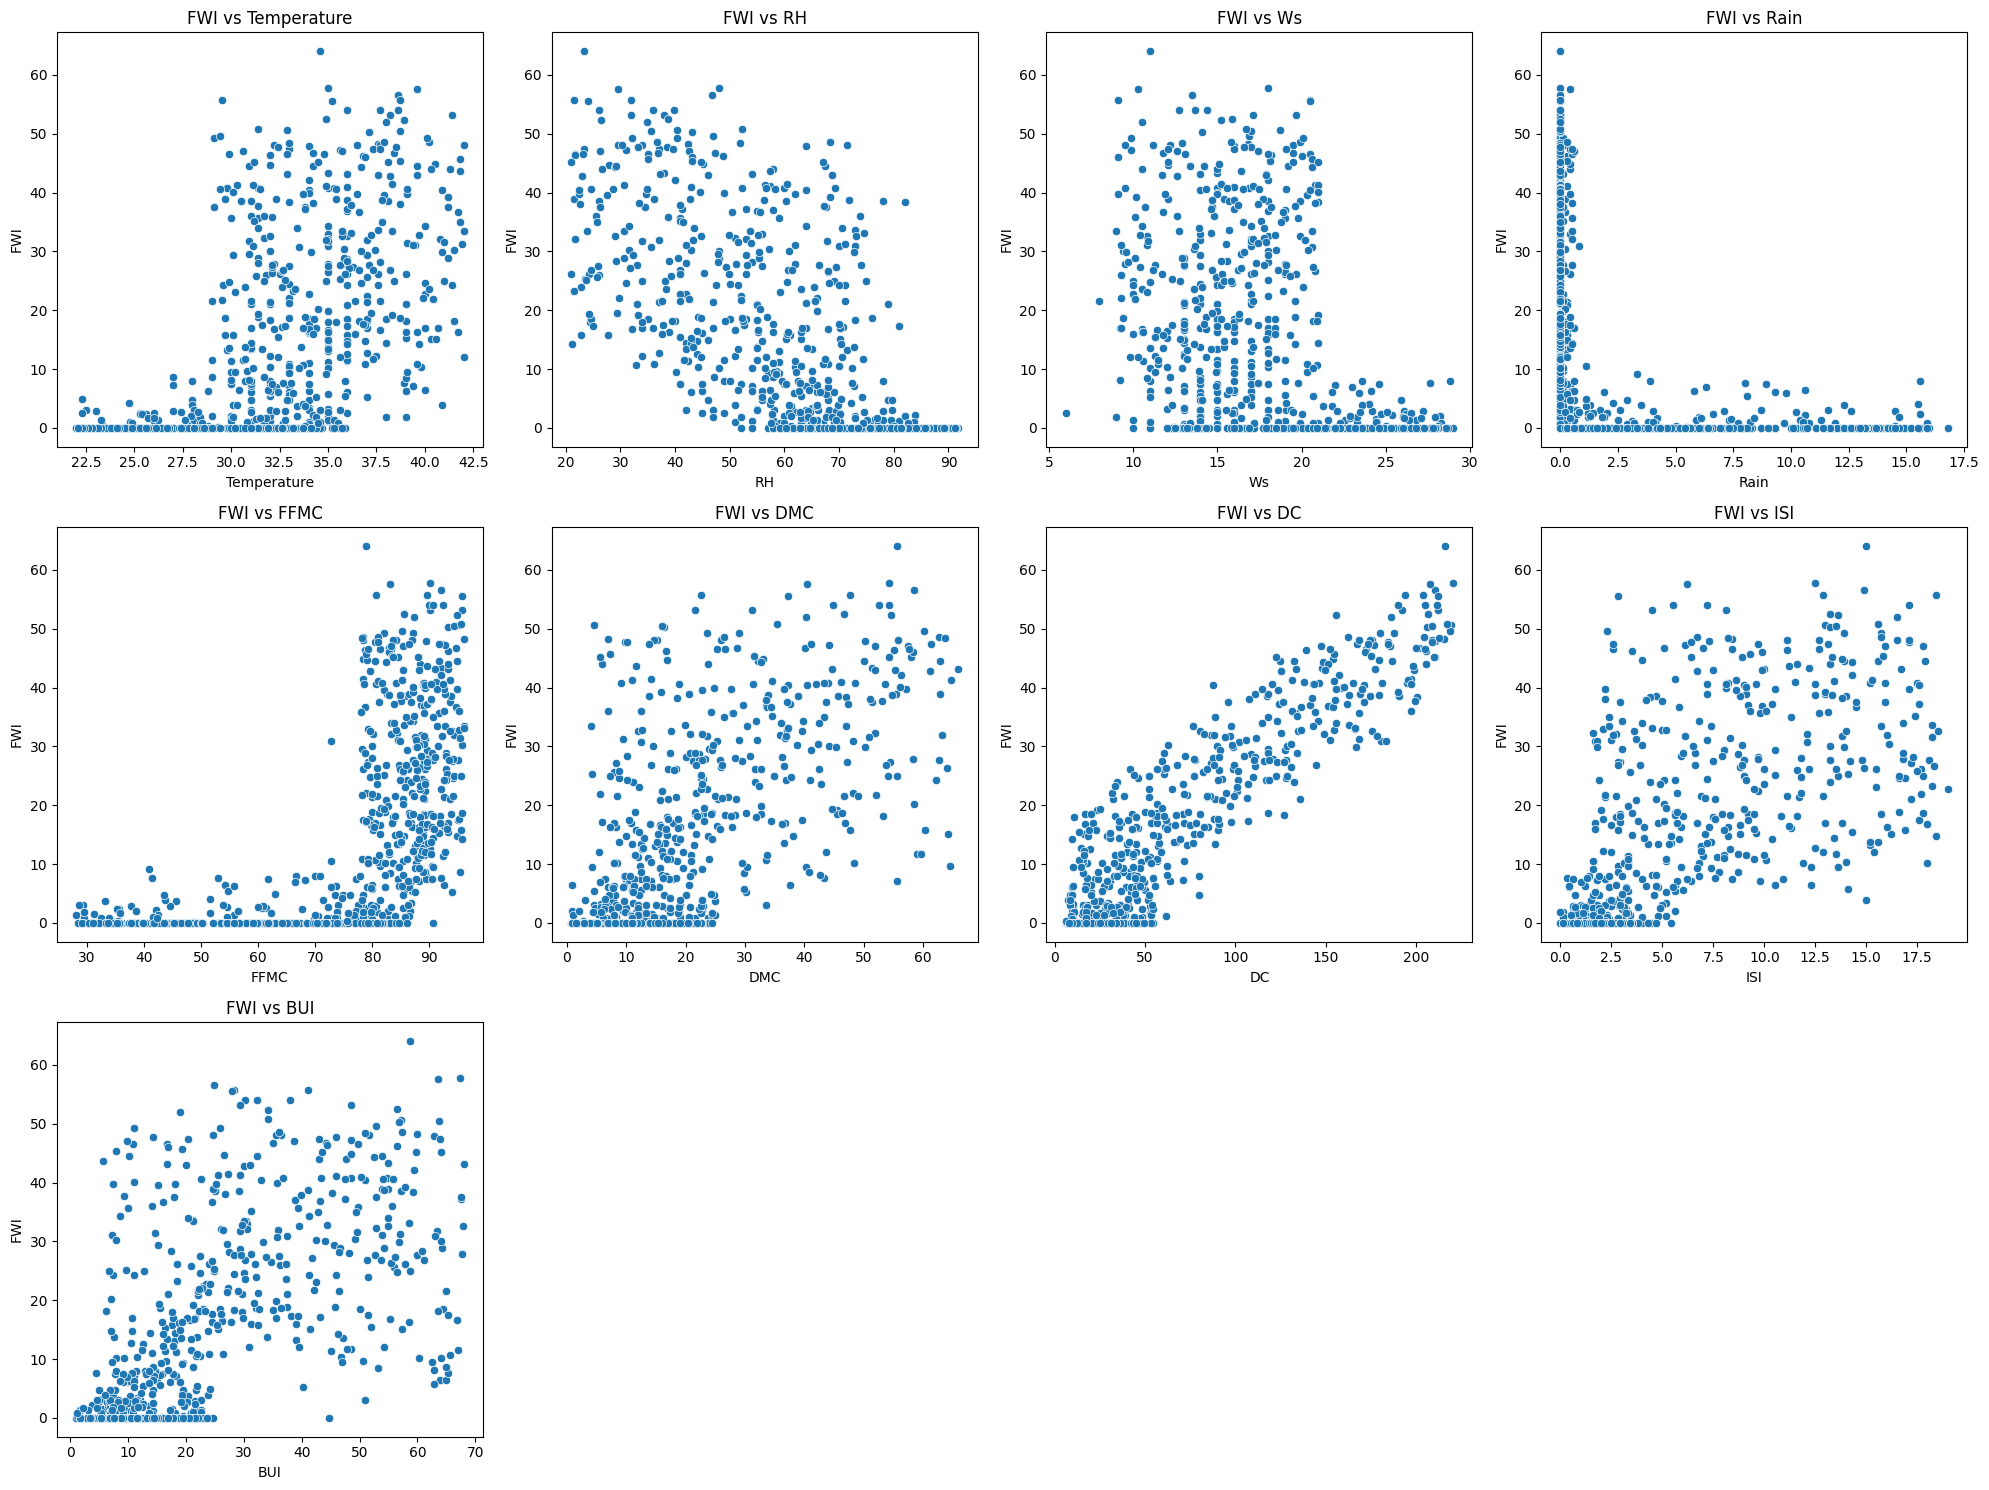

In [113]:
features = numeric_cols.drop("FWI")
n_cols = len(features)
n_rows = (n_cols // 4) + (1 if n_cols % 4 else 0)  # auto rows

plt.figure(figsize=(20, 5 * n_rows))
for i, col in enumerate(features, 1):
    plt.subplot(n_rows, 4, i)
    sns.scatterplot(x=df[col], y=df["FWI"])
    plt.title(f"FWI vs {col}")
plt.tight_layout()
plt.show()

Encoding categorical values

In [115]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])

#OR (as we know the categories)
#df['Region'] = df['Region'].map({'Karnataka': 0, 'Andhra Pradesh': 1})

In [116]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.0,1
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.0,1
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.0,1
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.0,1


In [117]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
719,29.0,81.3,27.8,3.3,78.8,15.3,31.4,3.4,3.3,0.000000,0
720,32.4,33.2,16.6,0.0,81.0,10.1,208.7,6.4,14.3,47.761119,0
721,26.0,72.9,26.1,8.4,35.7,24.5,32.1,3.2,2.2,1.747318,0
722,34.1,62.8,18.5,9.0,79.2,5.0,25.4,2.5,7.6,0.000000,1
723,31.0,68.7,18.5,10.1,55.8,1.6,8.0,2.0,19.4,0.000000,0


save the cleaned dataset

In [118]:
df.to_csv("cleaned_dataset.csv", index=False)

Step-3: Feature Engineering and scaling

Standard Scaling and Splitting the dataset

In [119]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [120]:
df = pd.read_csv("cleaned_dataset.csv")

In [121]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.0,1
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.0,1
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.0,1
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.0,1


Splitting training and testing data

In [122]:
X = df.drop("FWI", axis=1)

y = df["FWI"]

80%-Training data & 20%-Testing data

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Applying Scaler on data to normalize it

In [124]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Saving the scaler

In [125]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

### Step-4: Model Training

Train Models

In [126]:
from sklearn.linear_model import LinearRegression, RidgeCV, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [127]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (Tuned)": RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100]),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    print(f"{name}: {r2:.3f}")
    
    # print best alpha only for Ridge
    if name == "Ridge (Tuned)":
        print("Best alpha:", model.alpha_)

Linear Regression: 0.973
Ridge (Tuned): 0.973
Best alpha: 100.0
Lasso: 0.973
Decision Tree: 0.932
Random Forest: 0.972
Gradient Boosting: 0.977


saving ridge mode

In [128]:
ridge_model = models["Ridge (Tuned)"]

with open("ridge.pkl", "wb") as f:
    pickle.dump(ridge_model, f)


### Step-5: Evaluation

Evaluate the ridge regression model

Evaluation Metrics

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = ridge_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


MAE: 2.0922105605990033
RMSE: 2.5989837423849567
R²: 0.9734547879803317
